In [2]:
import pandas as pd
import numpy as np
import torch
import json
import os
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

In [3]:
print("Loading data and mapping files...")
meta_df = pd.read_parquet('../data/clean_meta.parquet')

with open('../data/processed/item_mapping.json', 'r') as f:
    item_mapping = json.load(f)

with open('../data/processed/user_mapping.json', 'r') as f:
    user_mapping = json.load(f)

user_item_edge_index = torch.load('../data/processed/user_item_edge_index.pt')

num_items = len(item_mapping)
num_users = len(user_mapping)
hidden_dim = 384 # Output dimension of all-MiniLM-L6-v2

print(f"Items to process: {num_items}")
print(f"Users to process: {num_users}")

Loading data and mapping files...
Items to process: 21639
Users to process: 1642


In [4]:
# 1. Prepare texts for all items in order of their mapped ID (0 to num_items-1)
# Create a reverse mapping (ID -> text)
item_texts = [""] * num_items

# We iterate over meta_df to map ASIN to Text, then place it in the correct ID slot
for idx, row in meta_df.iterrows():
    asin = row['asin']
    if asin in item_mapping:
        mapped_id = item_mapping[asin]
        
        # safely handle title
        title = row['title']
        # Use a type check to prevent the same array error if title is ever a list/array
        if isinstance(title, float) and pd.isna(title):
            title = ""
        else:
            title = str(title)
            
        # safely handle description which might be a list, numpy array, missing, or string
        desc = row['description']
        desc_str = ""
        
        # Catch lists, tuples, and numpy arrays FIRST
        if isinstance(desc, (list, tuple, np.ndarray)):
            desc_str = " ".join([str(x) for x in desc])
        # Now it is safe to use pd.notna() since we know it's a scalar value
        elif pd.notna(desc):
            desc_str = str(desc)
            
        full_text = f"{title}. {desc_str}".strip()
        
        # Clean up leading/trailing periods if one of the fields was empty
        if full_text.startswith(". "):
            full_text = full_text[2:]
            
        item_texts[mapped_id] = full_text

In [5]:
# 2. Encode Item Features
print("Loading sentence-transformer model (all-MiniLM-L6-v2)...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding text... This may take a few moments.")
# batch size can be customized, 32 or 64 is typical
item_features_np = model.encode(item_texts, show_progress_bar=True, batch_size=128)
item_features = torch.tensor(item_features_np, dtype=torch.float)

print(f"Successfully generated item features of shape: {item_features.shape}")

Loading sentence-transformer model (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding text... This may take a few moments.


Batches:   0%|          | 0/170 [00:00<?, ?it/s]

Successfully generated item features of shape: torch.Size([21639, 384])


In [6]:
# 3. Initialize User Features
print("Generating user features based on historical interaction means...")
user_features = torch.zeros((num_users, hidden_dim), dtype=torch.float)

u_nodes, i_nodes = user_item_edge_index

# Convert to pandas for quick grouping by user (numpy operations are also fine)
# For each user, get all item indices they interacted with
u_array = u_nodes.numpy()
i_array = i_nodes.numpy()

# We can use pd Series grouping or a simple loop depending on speed
from collections import defaultdict
user_to_items = defaultdict(list)
for u, i in zip(u_array, i_array):
    user_to_items[u].append(i)

# Calculate mean feature vectors for users
for u in range(num_users):
    items_interacted = user_to_items.get(u, [])
    if len(items_interacted) > 0:
        # get the embeddings for these items
        interacted_embs = item_features[items_interacted] # shape: [num_interactions, hidden_dim]
        mean_emb = torch.mean(interacted_embs, dim=0)
        user_features[u] = mean_emb
    else:
        # If no interactions (e.g., they only interacted with items outside the dataset or missing valid edges)
        # leave as zeros
        pass

print(f"Successfully generated user features of shape: {user_features.shape}")

Generating user features based on historical interaction means...
Successfully generated user features of shape: torch.Size([1642, 384])


## Feature Visualization (Trực quan hóa Đặc trưng)
Vì các đặc trưng (embeddings) là các mảng gồm 384 con số rất trừu tượng, chúng ta không thể nhìn trực tiếp được. Tuy nhiên, chúng ta có thể dùng 2 phương pháp sau để 'hình dung' chúng:
1. **Heatmap (Bản đồ nhiệt):** Xem trực tiếp sắc độ của các con số.
2. **PCA (Principal Component Analysis):** Ép không gian 384 chiều xuống còn mặt phẳng 2 chiều (X, Y) để xem các User và Item có phân bố xen kẽ nhau hay không.

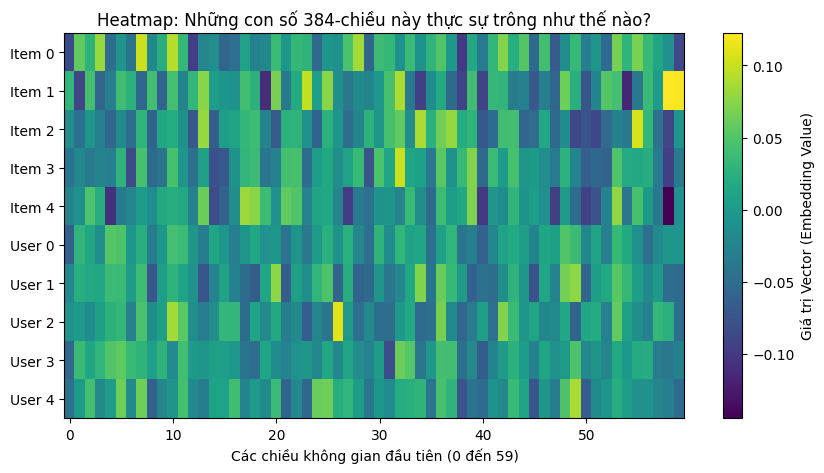

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_embedding_heatmap(item_embs, user_embs, num_samples=5):
    plt.figure(figsize=(10, 5))
    
    # Lấy mẫu một vài vector đầu tiên của User và Item
    sample_items = item_embs[:num_samples].numpy()
    sample_users = user_embs[:num_samples].numpy()
    
    combined = np.vstack([sample_items, sample_users])
    labels = [f"Item {i}" for i in range(num_samples)] + [f"User {i}" for i in range(num_samples)]
    
    # Lấy 60 con số (chiều) đầu tiên trong 384 chiều để vẽ cho đỡ rối mắt
    dim_to_show = 60
    combined_subset = combined[:, :dim_to_show]
    
    plt.imshow(combined_subset, cmap='viridis', aspect='auto')
    plt.colorbar(label='Giá trị Vector (Embedding Value)')
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.xlabel(f'Các chiều không gian đầu tiên (0 đến {dim_to_show-1})')
    plt.title('Heatmap: Những con số 384-chiều này thực sự trông như thế nào?')
    plt.show()

# Xem thử 5 Item và 5 User
plot_embedding_heatmap(item_features, user_features, num_samples=5)

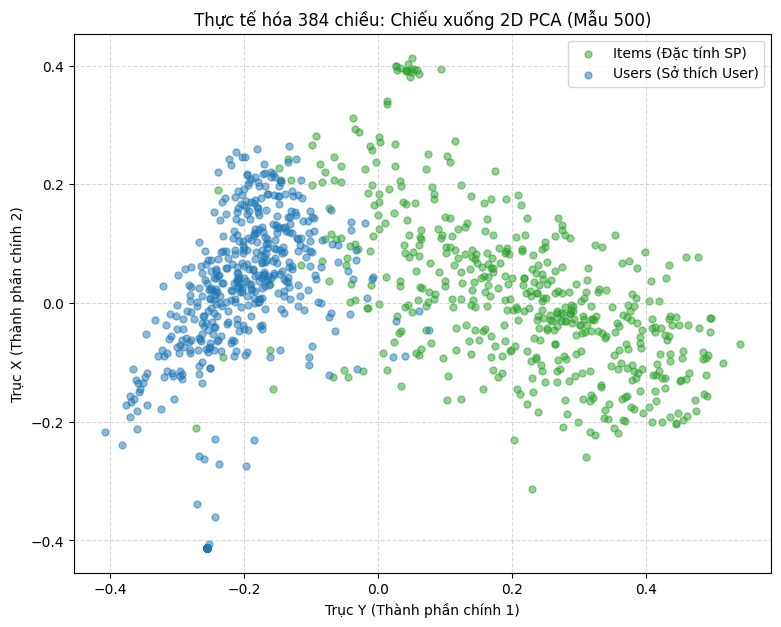

In [8]:
def plot_pca_embeddings(item_embs, user_embs, num_samples=500):
    # Lấy mẫu để tránh bị chậm máy
    item_sample = item_embs[:num_samples]
    user_sample = user_embs[:num_samples]
    
    # Lọc bỏ những User bị mảng toàn số 0 (chưa từng mua gì)
    valid_users = torch.sum(torch.abs(user_sample), dim=1) > 0
    user_sample = user_sample[valid_users]
    
    combined = torch.cat([item_sample, user_sample], dim=0)
    
    # Thuật toán PCA nén 384 chiều xuống 2 chiều (sử dụng khả năng toán học của PyTorch)
    mean = combined.mean(dim=0)
    centered = combined - mean
    U, S, V = torch.pca_lowrank(centered, q=2)
    reduced = torch.matmul(centered, V[:, :2])
    
    reduced_items = reduced[:item_sample.size(0)].numpy()
    reduced_users = reduced[item_sample.size(0):].numpy()
    
    plt.figure(figsize=(9, 7))
    plt.scatter(reduced_items[:, 0], reduced_items[:, 1], alpha=0.5, label='Items (Đặc tính SP)', c='#2ca02c', s=25)
    plt.scatter(reduced_users[:, 0], reduced_users[:, 1], alpha=0.5, label='Users (Sở thích User)', c='#1f77b4', s=25)
    
    plt.title(f'Thực tế hóa 384 chiều: Chiếu xuống 2D PCA (Mẫu {num_samples})')
    plt.xlabel('Trục Y (Thành phần chính 1)')
    plt.ylabel('Trục X (Thành phần chính 2)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Vẽ bản đồ 500 mạng lưới 
plot_pca_embeddings(item_features, user_features, num_samples=500)

In [7]:
# 4. Save to disk
torch.save(item_features, '../data/processed/x_dict_item.pt')
torch.save(user_features, '../data/processed/x_dict_user.pt')
print("Encoding complete! Artifacts saved to data/processed/")

Encoding complete! Artifacts saved to data/processed/
